In [1]:
# ===============================
# 📦 Standard Libraries
# ===============================
import os
import numpy as np
from glob import glob
from PIL import Image
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.io import loadmat

# ===============================
# 🔥 PyTorch Core
# ===============================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter
from torch.nn.utils import clip_grad_norm_
from torch.optim.lr_scheduler import OneCycleLR
from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR
from torchsummary import summary

# ===============================
# 🎨 torchvision
# ===============================
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

# Dataset Preparation

In [2]:
# === Load dataset with .mat parsing ===
class ShanghaiDataset(Dataset):
    def __init__(self, image_dir, gt_dir, transform=None, return_raw=False):
        self.image_paths = sorted(glob(os.path.join(image_dir, '*.jpg')))
        self.gt_paths = sorted(glob(os.path.join(gt_dir, 'GT_*.mat')))
        self.transform = transform
        self.return_raw = return_raw

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        raw_image = image.copy()  # keep for visualization

        if self.transform:
            image = self.transform(image)

        gt = loadmat(self.gt_paths[idx])
        count = len(gt['image_info'][0, 0][0, 0][0])

        if self.return_raw:
            return image, torch.tensor([count], dtype=torch.float32), raw_image
        else:
            return image, torch.tensor([count], dtype=torch.float32)

## Load Dataset

In [3]:
def custom_collate_fn(batch):
    imgs, targets, raws = zip(*batch)  # unzip the list of tuples
    return torch.stack(imgs), torch.stack(targets), raws

In [ ]:
def get_train_transform(level="moderate", input_size=256):
    """
    Return the train transform based on augmentation strength level.

    Args:
        level (str): "light", "moderate", or "strong"
        input_size (int): Size to resize images (default 256)
    Returns:
        torchvision.transforms.Compose
    """

    if level == "light":
        # Light augmentation: safest
        transform = transforms.Compose([
            transforms.Resize((input_size, input_size)),
            transforms.RandomApply([
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
            ], p=0.8),
            transforms.RandomGrayscale(p=0.1),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.5)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
        
    elif level == "moderate":
        # Moderate augmentation: slightly stronger
        transform = transforms.Compose([
            transforms.Resize((input_size, input_size)),
            transforms.RandomApply([
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
            ], p=0.8),
            transforms.RandomGrayscale(p=0.1),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    elif level == "strong":
        # Very strong augmentation: aggressive, risky
        transform = transforms.Compose([
            transforms.Resize((input_size, input_size)),
            transforms.RandomApply([
                transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1)
            ], p=0.9),
            transforms.RandomGrayscale(p=0.2),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=20),
            transforms.RandomPerspective(distortion_scale=0.5, p=0.7),
            transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
            transforms.GaussianBlur(kernel_size=(5, 5), sigma=(0.1, 2.0)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
        
    else:
        raise ValueError(f"Unknown augmentation level: {level}")

    return transform

In [ ]:
def load_shanghai_dataset(dataset_root, batch_size=16, use_augment=True, augment_level="light"):
    """
    Load ShanghaiTech Part A dataset.

    Args:
        dataset_root (str): Root path to ShanghaiTech dataset.
        batch_size (int): Batch size for DataLoader.
        use_augment (bool): Whether to apply strong augmentation for training set.

    Returns:
        train_loader, test_loader
    """

    # Define train/test paths
    train_images = os.path.join(dataset_root, "part_A_final/train_data/images")
    train_ground_truth = os.path.join(dataset_root, "part_A_final/train_data/ground_truth")
    test_images = os.path.join(dataset_root, "part_A_final/test_data/images")
    test_ground_truth = os.path.join(dataset_root, "part_A_final/test_data/ground_truth")

    # Define transforms
    if use_augment:
        train_transform = get_train_transform(level=augment_level)
    else:
        train_transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    test_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # Create datasets
    trainset = ShanghaiDataset(train_images, train_ground_truth, transform=train_transform)
    testset = ShanghaiDataset(test_images, test_ground_truth, transform=test_transform, return_raw=True)

    # Create dataloaders
    train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(testset, batch_size=1, shuffle=False, collate_fn=custom_collate_fn, num_workers=4, pin_memory=True, persistent_workers=True)

    return train_loader, test_loader

# Model Definitions

In [6]:
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet18, ResNet18_Weights,
    mobilenet_v2, MobileNet_V2_Weights,
    shufflenet_v2_x0_5, ShuffleNet_V2_X0_5_Weights,
    mobilenet_v3_small, MobileNet_V3_Small_Weights,
    mnasnet0_5, MNASNet0_5_Weights
)

# Mapping between model names and their constructors + final layer names
model_configs = {
    'efficientnet_b0': (efficientnet_b0, EfficientNet_B0_Weights.DEFAULT, 'classifier'),
    'resnet18': (resnet18, ResNet18_Weights.DEFAULT, 'fc'),
    'mobilenet_v2': (mobilenet_v2, MobileNet_V2_Weights.DEFAULT, 'classifier'),
    'shufflenet_v2_x0_5': (shufflenet_v2_x0_5, ShuffleNet_V2_X0_5_Weights.DEFAULT, 'fc'),
    'mobilenet_v3_small': (mobilenet_v3_small, MobileNet_V3_Small_Weights.DEFAULT, 'classifier'),
    'mnasnet0_5': (mnasnet0_5, MNASNet0_5_Weights.DEFAULT, 'classifier')
}

def get_model(name):
    if name not in model_configs:
        raise ValueError(f"Model '{name}' is not supported.")
    
    constructor, weights, head = model_configs[name]
    model = constructor(weights=weights)

    if head == 'classifier':
        model.classifier[-1] = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(model.classifier[-1].in_features, 1)
        )
    elif head == 'fc':
        model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, 1)
        )

    return model

# Training Utilities

In [7]:
def save_checkpoint(model, optimizer, epoch, path):
    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch
    }, path)

In [8]:
def count_parameters(model):
    """ Count the number of trainable parameters in the model.
    Args:
        model (nn.Module): The model to count parameters for.
    Returns:
        int: The number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [11]:
import numpy as np
import torch

# CutMix augmentation
def cutmix_data(x, y, alpha=1.0):
    """
    Apply CutMix augmentation on a batch of images and labels.

    Args:
        x (Tensor): Batch of input images [B, C, H, W].
        y (Tensor): Batch of target counts [B, 1].
        alpha (float): Hyperparameter for Beta distribution.

    Returns:
        mixed_x: Mixed input images
        mixed_y: Mixed target counts
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    # Get the bounding box for CutMix
    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    
    new_x = x.clone()
    new_x[:, :, bbx1:bbx2, bby1:bby2] = x[index, :, bbx1:bbx2, bby1:bby2]

    # Adjust lambda based on the actual area
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (x.size(-1) * x.size(-2)))

    # Targets: linear combination
    y_a, y_b = y, y[index]
    mixed_y = lam * y_a + (1 - lam) * y_b

    return new_x, mixed_y

def rand_bbox(size, lam):
    """
    Generate random bounding box.
    Args:
        size: shape of the input tensor (batch_size, channels, height, width)
        lam: lambda value from Beta distribution

    Returns:
        Coordinates (x1, y1, x2, y2) for the bounding box
    """
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)  # ratio of cut region
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    # Uniform random center
    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

In [12]:
# Calculate Mean Absolute Error (MAE) and Tolerance-based Accuracy with Tolerance is ±20%
def evaluate_model_mae_tolerance(model, loader, device, tolerance=0.2):
    """
    Evaluate the model on the given loader and compute:
      - Mean Absolute Error (MAE)
      - Tolerance-based accuracy

    Args:
        model: Trained PyTorch model
        loader: DataLoader
        device: CPU or CUDA
        tolerance: Tolerance margin (default 0.2 for ±20%)

    Returns:
        (mae, tolerance_accuracy): tuple of floats
    """
    model.eval()
    val_mae_sum = 0.0
    pred_list = []
    target_list = []

    with torch.no_grad():
        for batch in loader:
            if len(batch) == 3:
                imgs, targets, _ = batch
            else:
                imgs, targets = batch

            imgs, targets = imgs.to(device), targets.to(device)
            preds = model(imgs).view(-1)
            targets = targets.view(-1)

            val_mae_sum += torch.abs(preds - targets).sum().item()

            pred_list.append(preds)
            target_list.append(targets)

    # Calculate MAE
    mae = val_mae_sum / len(loader.dataset)

    # Calculate Tolerance-based Accuracy
    preds_all = torch.cat(pred_list)
    targets_all = torch.cat(target_list)

    lower_bound = targets_all * (1 - tolerance)
    upper_bound = targets_all * (1 + tolerance)
    correct = ((preds_all >= lower_bound) & (preds_all <= upper_bound)).sum().item()
    tol_acc = (correct / targets_all.size(0)) * 100

    return mae, tol_acc

In [13]:
from torchinfo import summary
from ptflops import get_model_complexity_info

def summarize_model(model, input_size=(3, 256, 256), print_summary=True):
    """
    Summarizes the model architecture, parameters, FLOPs.

    Args:
        model (nn.Module): PyTorch model
        input_size (tuple): Input tensor size (C, H, W)
        print_summary (bool): Whether to print the structure or just return values.

    Returns:
        gflops (float): Total FLOPs (GFLOPS)
        params_million (float): Total number of parameters (Million)
    """
    model = model.cpu()
    model.eval()

    if print_summary:
        print("\n🧠 Model Structure Summary:")
        info = summary(
            model,
            input_size=(1, *input_size),
            depth=2,
            col_names=["input_size", "output_size", "num_params"],
            verbose=0
        )
        print(info)

    # Calculate MACs and Params
    macs, params = get_model_complexity_info(
        model,
        input_res=input_size,
        as_strings=False,
        print_per_layer_stat=False,
        verbose=False
    )

    gflops = macs / 1e9
    params_million = params / 1e6

    if print_summary:
        print("\n📏 Model Size and Complexity:")
        print(f"⚡ GFLOPS: {gflops:.4f}")
        print(f"📦 Parameters: {params_million:.2f} Million")

    return gflops, params_million

In [14]:
class TrainingLogger:
    def __init__(self, model_name, base_log_dir="runs/train"):
        self.model_name = model_name
        self.timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.experiment_dir = os.path.join(base_log_dir, model_name, self.timestamp)
        os.makedirs(self.experiment_dir, exist_ok=True)

        self.log_filename = f"{model_name}_trainlog.txt"
        self.log_filepath = os.path.join(self.experiment_dir, self.log_filename)

        # Create the log file header
        with open(self.log_filepath, "w") as f:
            f.write(f"Training Log for Model: {self.model_name}\n")
            f.write(f"Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write("="*60 + "\n")

    def log_train_config(self, config):
        """Log the training configuration settings."""
        with open(self.log_filepath, "a") as f:
            f.write("📋 Train Config:\n")
            f.write(f"Model Name: {config.model_name}\n")
            f.write(f"Num Epochs: {config.num_epochs}\n")
            f.write(f"Learning Rate: {config.lr}\n")
            f.write(f"Patience: {config.patience}\n")
            f.write(f"Use CutMix: {config.use_cutmix} (Alpha={config.cutmix_alpha})\n")
            f.write(f"Use Augment: {config.use_augment}\n")
            f.write(f"Use Grad Clip: {config.use_grad_clip} (Max Norm={config.grad_clip_max_norm})\n")
            f.write(f"Resize: (256, 256)\n")  
            f.write(f"Loss Function: L1Loss\n")
            f.write("="*60 + "\n")

    def log_model_summary(self, gflops, params_million):
        """Log model architecture summary."""
        with open(self.log_filepath, "a") as f:
            f.write("\n🧠 Model Summary:\n")
            f.write(f"GFLOPS: {gflops:.4f}\n")
            f.write(f"Params: {params_million:.2f} Million\n")
            f.write("="*60 + "\n")

    def log_epoch(self, message):
        with open(self.log_filepath, "a") as f:
            f.write(message + "\n")

    def log_best_checkpoint(self, best_epoch, best_val_tol_acc):
        with open(self.log_filepath, "a") as f:
            f.write(f"✅ Best checkpoint updated at Epoch {best_epoch} | Val TolAcc: {best_val_tol_acc:.2f}%\n")

    def finalize(self, best_epoch, best_val_tol_acc, best_val_mae, model_score):
        with open(self.log_filepath, "a") as f:
            f.write("\n" + "="*60 + "\n")
            f.write("🏁 Final Training Summary:\n")
            f.write(f"⭐ Best Epoch: {best_epoch}\n")
            f.write(f"✅ Best Validation Tolerance Accuracy: {best_val_tol_acc:.2f}%\n")
            f.write(f"📏 Corresponding Validation MAE: {best_val_mae:.2f}\n")
            f.write(f"🏆 Final Model Score: {model_score:.4f}\n")
            f.write(f"🕒 End Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write("="*60 + "\n")

    def get_experiment_dir(self):
        return self.experiment_dir

    def get_log_path(self):
        return self.log_filepath

In [15]:
class TrainConfig:
    """
    Configuration object for training.
    Contains all hyperparameters and settings.
    """
    def __init__(
        self,
        model_name="shufflenet_v2_x0_5",
        dataset_root="path/to/dataset",
        num_epochs=250,
        lr=0.001,
        patience=50,
        batch_size=16,
        use_cutmix=True,
        cutmix_alpha=1.5,
        use_grad_clip=True,
        grad_clip_max_norm=1.0,
        use_augment=True,
        loss_type="l1",  
        input_size=256,  # input image size (256x256 default)
        base_log_dir="runs/train"  # log saving
    ):
        self.model_name = model_name
        self.dataset_root = dataset_root
        self.num_epochs = num_epochs
        self.lr = lr
        self.patience = patience
        self.batch_size = batch_size
        self.use_cutmix = use_cutmix
        self.cutmix_alpha = cutmix_alpha
        self.use_grad_clip = use_grad_clip
        self.grad_clip_max_norm = grad_clip_max_norm
        self.use_augment = use_augment
        self.loss_type = loss_type
        self.input_size = input_size
        self.base_log_dir = base_log_dir

        # Filled after summarizing the model
        self.log_dir = None
        self.model_gflops = None
        self.model_params_million = None

In [16]:
def finalize_model_evaluation(config: TrainConfig, train_loader, test_loader, device, best_epoch, logger, tolerance=0.2):
    """
    Reload the best checkpoint, evaluate on test set, calculate final model score,
    and finalize the training log.

    Args:
        config (TrainConfig): Configuration object
        train_loader (DataLoader): Training set loader
        test_loader (DataLoader): Test set loader
        device (torch.device): CUDA or CPU
        best_epoch (int): Best epoch where checkpoint saved
        logger (TrainingLogger): Logger to record the final summary
        tolerance (float): Tolerance margin for accuracy (default: ±20%)
    """
    # 🚀 Reload best checkpoint
    model = get_model(config.model_name).to(device)
    checkpoint_path = os.path.join(config.log_dir, f"{config.model_name}_best.pth")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])

    # 📈 Evaluate on test set
    best_val_mae, best_val_tol_acc = evaluate_model_mae_tolerance(model, test_loader, device, tolerance)

    # 🧮 Calculate final model score
    total_train_images = len(train_loader.dataset)
    model_score = (1 - (best_val_tol_acc / 100)) * config.model_gflops * config.model_params_million * total_train_images

    # 🖨️ Print final summary
    print("\n🚀 Final Model Analysis:")
    print(f"⭐ Best Epoch: {best_epoch}")
    print(f"⚡ GFLOPS: {config.model_gflops:.4f}")
    print(f"📦 Params: {config.model_params_million:.2f} Million")
    print(f"✅ Best Val Tolerance Accuracy: {best_val_tol_acc:.2f}%")
    print(f"📏 Corresponding Val MAE: {best_val_mae:.2f}")
    print(f"🏆 Final Model Score: {model_score:.4f}")

    # 📓 Log final summary
    logger.finalize(best_epoch, best_val_tol_acc, best_val_mae, model_score)

    return model_score

# Main Training Function

In [17]:
import random

def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Inside train_model
set_random_seed(42)

In [ ]:
def train_model(config: TrainConfig):
    """
    Full training loop with CutMix, Gradient Clipping, AdamW, and One-Cycle LR scheduling.

    Args:
        config (TrainConfig): Configuration object containing all hyperparameters and paths.
    """
    # 🛠️ Setup device, directories, TensorBoard, Logger
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 📓 Initialize Training Logger (each experiment gets a new folder)
    logger = TrainingLogger(config.model_name)
    config.log_dir = logger.get_experiment_dir()
    writer = SummaryWriter(log_dir=config.log_dir)

    # 📋 Log the training configuration immediately
    logger.log_train_config(config)

    # 📦 Load dataset
    train_loader, test_loader = load_shanghai_dataset(
        config.dataset_root,
        batch_size=config.batch_size,
        use_augment=config.use_augment,
        augment_level="moderate"
    )
    print(f"Train Images: {len(train_loader.dataset)}  |  Test Images: {len(test_loader.dataset)}")

    # 🧠 Model initialization & graph logging
    model = get_model(config.model_name).to(device)
    dummy_input = torch.randn(1, 3, 256, 256, device=device)
    writer.add_graph(model, dummy_input)

    # 🧠 Model Summary (GFLOPS + Params)
    gflops, params_million = summarize_model(model, print_summary=True)
    logger.log_model_summary(gflops, params_million)
    config.model_gflops = gflops
    config.model_params_million = params_million

    # ⚡ Loss, optimizer, scheduler
    criterion = nn.L1Loss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=1e-4)
    total_steps = config.num_epochs * len(train_loader)
    scheduler = OneCycleLR(
        optimizer,
        max_lr=config.lr,
        total_steps=total_steps,
        pct_start=0.1,
        anneal_strategy='cos'
    )

    # 📈 Tracking variables
    best_val_tol_acc = 0.0
    best_epoch = 0
    epochs_no_improve = 0

    # 🚀 Main training loop
    for epoch in range(1, config.num_epochs + 1):
        model.train()

        for imgs, targets in train_loader:
            imgs, targets = imgs.to(device), targets.to(device)

            # 🎨 CutMix data augmentation
            if config.use_cutmix and np.random.rand() < 0.5:
                imgs, targets = cutmix_data(imgs, targets, alpha=config.cutmix_alpha)

            preds = model(imgs).view(-1)
            loss = criterion(preds, targets.view(-1))

            optimizer.zero_grad()
            loss.backward()

            # ✂️ Gradient clipping
            if config.use_grad_clip:
                clip_grad_norm_(model.parameters(), max_norm=config.grad_clip_max_norm)

            optimizer.step()
            scheduler.step()

        # 📈 Evaluation after epoch
        train_mae, train_tol_acc = evaluate_model_mae_tolerance(model, train_loader, device, tolerance=0.2)
        val_mae, val_tol_acc = evaluate_model_mae_tolerance(model, test_loader, device, tolerance=0.2)

        # 🖊️ Logging to TensorBoard
        writer.add_scalar(f"{config.model_name}/MAE/Train", train_mae, epoch)
        writer.add_scalar(f"{config.model_name}/MAE/Val", val_mae, epoch)
        writer.add_scalar(f"{config.model_name}/TolAcc/Train", train_tol_acc, epoch)
        writer.add_scalar(f"{config.model_name}/TolAcc/Val", val_tol_acc, epoch)

        # 📓 Prepare log message
        log_msg = (
            f"[{config.model_name}] Epoch {epoch}/{config.num_epochs} | "
            f"Train MAE: {train_mae:.2f} ({train_tol_acc:.2f}% TolAcc) | "
            f"Val MAE: {val_mae:.2f} ({val_tol_acc:.2f}% TolAcc) | "
            f"LR: {optimizer.param_groups[0]['lr']:.1e}"
        )

        # 💾 Save checkpoint if better
        if val_tol_acc > best_val_tol_acc:
            best_val_tol_acc = val_tol_acc
            best_epoch = epoch
            epochs_no_improve = 0
            path = os.path.join(config.log_dir, f"{config.model_name}_best.pth")
            save_checkpoint(model, optimizer, epoch, path)
            writer.add_scalar(f"{config.model_name}/TolAcc/BestVal", best_val_tol_acc, epoch)
            logger.log_best_checkpoint(best_epoch, best_val_tol_acc)
            log_msg += " ✅ Saved"
        else:
            epochs_no_improve += 1

        print(log_msg)
        logger.log_epoch(log_msg)

        # 🛑 Early stopping
        if epochs_no_improve >= config.patience:
            print(f"Early stopping at epoch {epoch} (no improvement for {config.patience} epochs)")
            break

    # 🏁 End of training
    writer.close()

    # 🔥 Final evaluation and model score calculation
    model_score = finalize_model_evaluation(config, train_loader, test_loader, device, best_epoch=best_epoch, logger=logger, tolerance=0.2)

    return model_score

# Training and Evaluation

## ShuffleNet

In [33]:
train_config_shufflenet = TrainConfig(
    model_name="shufflenet_v2_x0_5",
    num_epochs=300,
    lr=0.001,
    patience=60,
    batch_size=16,
    use_cutmix=True,
    cutmix_alpha=1,
    use_grad_clip=True,
    grad_clip_max_norm=1.0,
    dataset_root="/home/wins057/Documents/Projects/python-for-dl-homework/week10/dataset/ShanghaiTech_Crowd_Counting_Dataset",
    use_augment=True
)

In [34]:
train_model(train_config_shufflenet)

Train Images: 300  |  Test Images: 182

🧠 Model Structure Summary:
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ShuffleNetV2                             [1, 3, 256, 256]          [1, 1]                    --
├─Sequential: 1-1                        [1, 3, 256, 256]          [1, 24, 128, 128]         --
│    └─Conv2d: 2-1                       [1, 3, 256, 256]          [1, 24, 128, 128]         648
│    └─BatchNorm2d: 2-2                  [1, 24, 128, 128]         [1, 24, 128, 128]         48
│    └─ReLU: 2-3                         [1, 24, 128, 128]         [1, 24, 128, 128]         --
├─MaxPool2d: 1-2                         [1, 24, 128, 128]         [1, 24, 64, 64]           --
├─Sequential: 1-3                        [1, 24, 64, 64]           [1, 48, 32, 32]           --
│    └─InvertedResidual: 2-4             [1, 24, 64, 64]           [1, 48, 32, 32]           2,400
│    └─InvertedResidual: 2-5             [1, 48, 32, 32]    

2.87361514251132

## MobileNet_v3_small

In [21]:
# train_config_mobilenet_v3 = TrainConfig(
#     model_name="mobilenet_v3_small",
#     num_epochs=250,
#     lr=0.0005,
#     patience=50,
#     log_dir="runs/train/mobilenet_v3_small",
#     use_cutmix=True,
#     cutmix_alpha=1,
#     use_grad_clip=True,
#     grad_clip_max_norm=1.0,
#     dataset_root="/home/wins057/Documents/Projects/python-for-dl-homework/week10/dataset/ShanghaiTech_Crowd_Counting_Dataset",
#     use_augment=True
# )
# train_model(train_config_mobilenet_v3)

## Evaluation

In [22]:
def load_best_model(config: TrainConfig, device):
    model = get_model(config.model_name).to(device)
    ckpt_path = os.path.join(config.log_dir, f"{config.model_name}_best.pth")
    checkpoint = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model

In [23]:
def predict_on_test_set(model, test_loader, device, max_images=4):
    model.eval()
    predictions, ground_truth = [], []
    raw_images, preds_to_plot, gts_to_plot = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            # Check if raw images are included
            if len(batch) == 3:
                imgs, targets, raws = batch
            else:
                imgs, targets = batch
                raws = [None] * len(imgs)

            imgs, targets = imgs.to(device), targets.to(device)
            preds = model(imgs).view(-1)

            predictions.extend(preds.cpu().numpy().tolist())
            ground_truth.extend(targets.cpu().numpy().tolist())

            # Store raw images for display
            if len(raw_images) < max_images:
                for i in range(min(len(imgs), max_images - len(raw_images))):
                    raw_img = raws[i]
                    if not isinstance(raw_img, Image.Image):
                        try:
                            raw_img = Image.fromarray(raw_img)
                        except Exception:
                            continue
                    raw_images.append(raw_img)
                    preds_to_plot.append(preds[i].item())
                    gts_to_plot.append(targets[i].item())

    # === Flatten and round predictions ===
    predictions = np.array(predictions).flatten().tolist()
    ground_truth = np.array(ground_truth).flatten().tolist()
    predictions = [round(p, 2) for p in predictions]
    ground_truth = [round(gt, 2) for gt in ground_truth]

    # === Plot raw images with prediction/GT ===
    if raw_images:
        fig, axs = plt.subplots(1, len(raw_images), figsize=(16, 4))
        for i, ax in enumerate(axs):
            ax.imshow(raw_images[i])
            ax.axis("off")
            ax.set_title(f"Pred: {preds_to_plot[i]:.1f} | GT: {gts_to_plot[i]:.1f}")
        plt.tight_layout()
        plt.show()

    return predictions, ground_truth

In [24]:
def plot_prediction_vs_ground_truth(model, test_loader, device):
    """
    Predicts on the test set and plots predicted counts vs ground truth counts.

    Args:
        model: Trained PyTorch model
        test_loader: DataLoader for test set
        device: CPU or CUDA
    """
    model.eval()
    predictions = []
    ground_truths = []

    with torch.no_grad():
        for batch in test_loader:
            if len(batch) == 3:
                imgs, targets, _ = batch
            else:
                imgs, targets = batch

            imgs, targets = imgs.to(device), targets.to(device)
            preds = model(imgs).view(-1)

            predictions.extend(preds.cpu().numpy().tolist())
            ground_truths.extend(targets.cpu().numpy().tolist())

    predictions = np.array(predictions).flatten()
    ground_truths = np.array(ground_truths).flatten()

    # === Plotting ===
    plt.figure(figsize=(8, 6))
    plt.scatter(ground_truths, predictions, alpha=0.5)
    plt.plot(
        [ground_truths.min(), ground_truths.max()],
        [ground_truths.min(), ground_truths.max()],
        'r--', label="Ideal: Pred = GT"
    )
    plt.xlabel('Ground Truth Count')
    plt.ylabel('Predicted Count')
    plt.title('Prediction vs Ground Truth')
    plt.legend()
    plt.grid(True)
    plt.show()

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the dataset for testing
train_loader, test_loader = load_shanghai_dataset(
    train_config_shufflenet.dataset_root,
    batch_size=16,
    use_augment=train_config_shufflenet.use_augment
)
# Load best model
model = load_best_model(train_config_shufflenet, device)

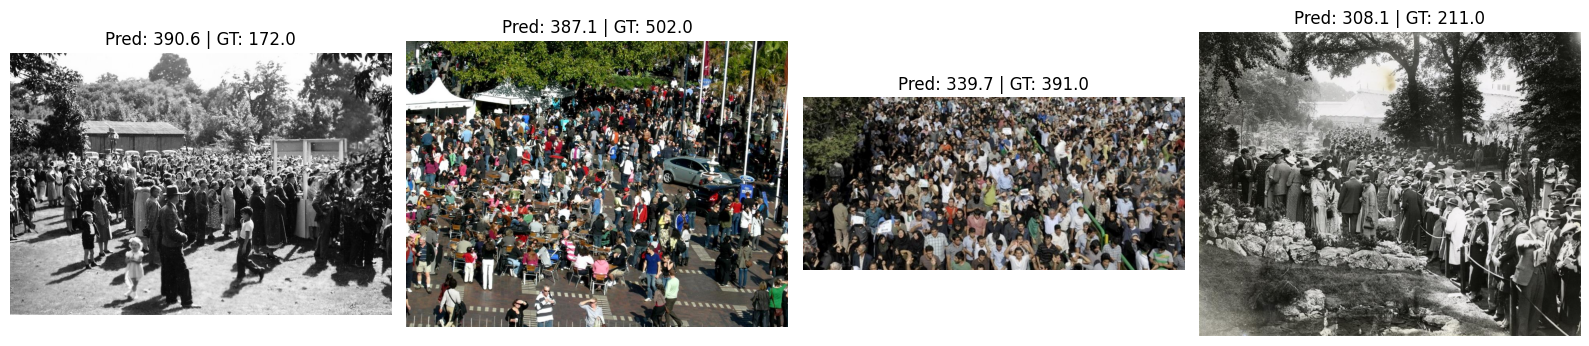

In [26]:
# Get predictions
preds, gts = predict_on_test_set(model, test_loader, device, max_images=4)

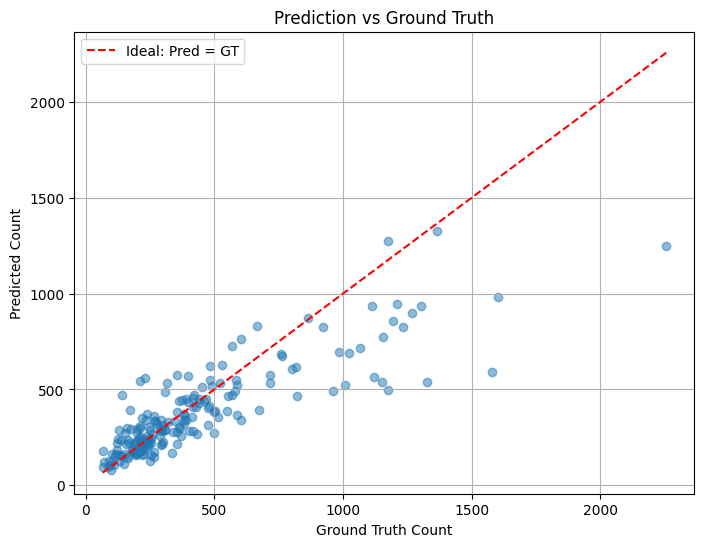

In [27]:
# Print predictions and ground truths
plot_prediction_vs_ground_truth(model, test_loader, device)

# TensorBoard Visualization

In [28]:
import subprocess
import time
import webbrowser

def start_tensorboard(logdir="runs", port=6006):
    """
    Starts TensorBoard as a background process and opens it in your default browser.
    Returns the process handle so you can terminate it later.
    """
    tb_cmd = [
        "tensorboard",
        f"--logdir={logdir}",
        f"--port={port}",
        "--host=localhost"
    ]
    
    # Start the process
    print(f"Starting TensorBoard on port {port}...")
    process = subprocess.Popen(tb_cmd)
    
    # Give it a second to get going
    time.sleep(2)
    
    # Open in browser automatically
    url = f"http://localhost:{port}"
    print(f"Opening {url} in your default browser...")
    webbrowser.open(url)
    
    return process


def stop_tensorboard(process):
    """
    Stops the TensorBoard process started by `start_tensorboard()`.
    """
    print("Stopping TensorBoard...")
    process.terminate()  # or process.kill()

In [29]:
process = start_tensorboard(logdir="runs", port=6009)

Starting TensorBoard on port 6009...


TensorFlow installation not found - running with reduced feature set.

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

E0428 20:55:36.837040 127556130903872 program.py:300] TensorBoard could not bind to port 6009, it was already in use
ERROR: TensorBoard could not bind to port 6009, it was already in use


Opening http://localhost:6009 in your default browser...


In [30]:
# stop_tensorboard(process)
# Uncomment the line below to stop TensorBoard when you're done